# Initial State Plot

Create a lattice initial state, convert it to the package bitstring format, and plot it.

initial_state = 022122022122122022122022022122022122122022122022


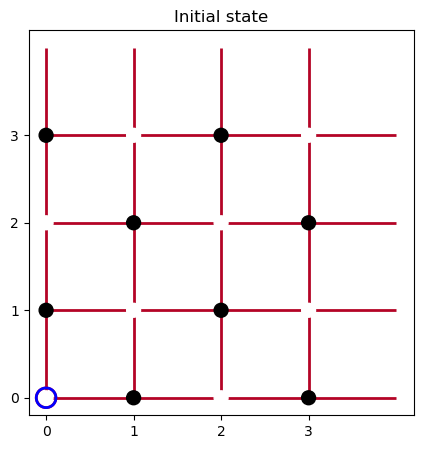

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Lets the notebook import the local package without installing it first.
sys.path.insert(0, str(Path.cwd() / "src"))

from U1_boson_fermion import converter_b2f, converter_f2s, plot_lattice_fermion, ham


# Lattice size and spin.
Lx = 4
Ly = 4
S = 1

# Matter occupation: checkerboard pattern.
num = np.array([
    [0, 1, 0, 1],
    [1, 0, 1, 0],
    [0, 1, 0, 1],
    [1, 0, 1, 0],
])

# Spin-1 link values can be -1, 0, or 1.
hor = np.ones((Ly, Lx))
ver = np.ones((Ly, Lx))

# Convert arrays to the compact initial-state bitstring.
initial_state = converter_f2s("file2binary", [num, hor, ver], s=S)
print("initial_state =", initial_state)

# Convert back to arrays for plotting.
site_val, link_values_y, link_values_x = converter_b2f(initial_state, lx=Lx, ly=Ly, s=S)

fig, ax = plt.subplots(figsize=(5, 5))
plot_lattice_fermion(
    ax=ax,
    Lx=Lx,
    Ly=Ly,
    site_val=site_val,
    link_values_x=link_values_x,
    link_values_y=link_values_y,
    t="/",
    m="/",
    J="/",
    g="/",
    chi="/",
    pp=[0, 0],
    pe=[0, 0],
    s=S,
)
ax.set_title("Initial state")
plt.show()
